# Heart Risk Prediction using Machine Learning

In [304]:
import sklearn
import numpy as np
import io
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.simplefilter(action='ignore')
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
kfold = StratifiedKFold(n_splits=5)

import missingno as msno

import util

## *Data Loading from Source*

### Using UCI  heart risk data used at kaggle competition
- Download UCI Cleveland heart risk data available on Kaggle
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [305]:
df_heart_disease = pd.read_csv('heart_disease_dataset_UCI.csv')

In [306]:
df_heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Description of feature vectors:

- **age**: The person's age in years
- **sex**: The person's sex (1 = male, 0 = female)
- **cp**:         
        0 = typical angina
        1 = atypical angina
        2 = non-anginal pain
        3 = asymptomatic
- **trestbps**: The person's resting blood pressure (mm Hg on admission to the hospital)
- **chol**: The person's cholesterol measurement in mg/dl
- **fbs**: The person's fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
- **restecg**: Resting electrocardiographic measurement (0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria)
- **thalach**: The person's maximum heart rate achieved
- **exang**: Exercise induced angina (1 = yes; 0 = no)
- **oldpeak**: ST depression induced by exercise relative to rest ('ST' relates to positions on the ECG plot. See more here)
- **slope**: 
        0 = upsloping
        1 = flat
        2 = downsloping
- **ca**: The number of major vessels (0-3)
- **thal**: A blood disorder called thalassemia 
        0: NULL (dropped from the dataset previously)
        1: fixed defect (no blood flow in some part of the heart)
        2: normal blood flow
        3: reversible defect (a blood flow is observed but it is not normal)
- **target**: Heart disease (0 = no, 1 = yes)



## Data Pre-Processing:
- Data cleaning 
- Remove NANs
- Look for missing and unimportant data

***Check for Null and NANs***
Need to convert object types to numerical types

In [307]:
df_heart_disease.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [308]:
df_heart_disease.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [309]:
df_heart_disease.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

***Visualize missing value***

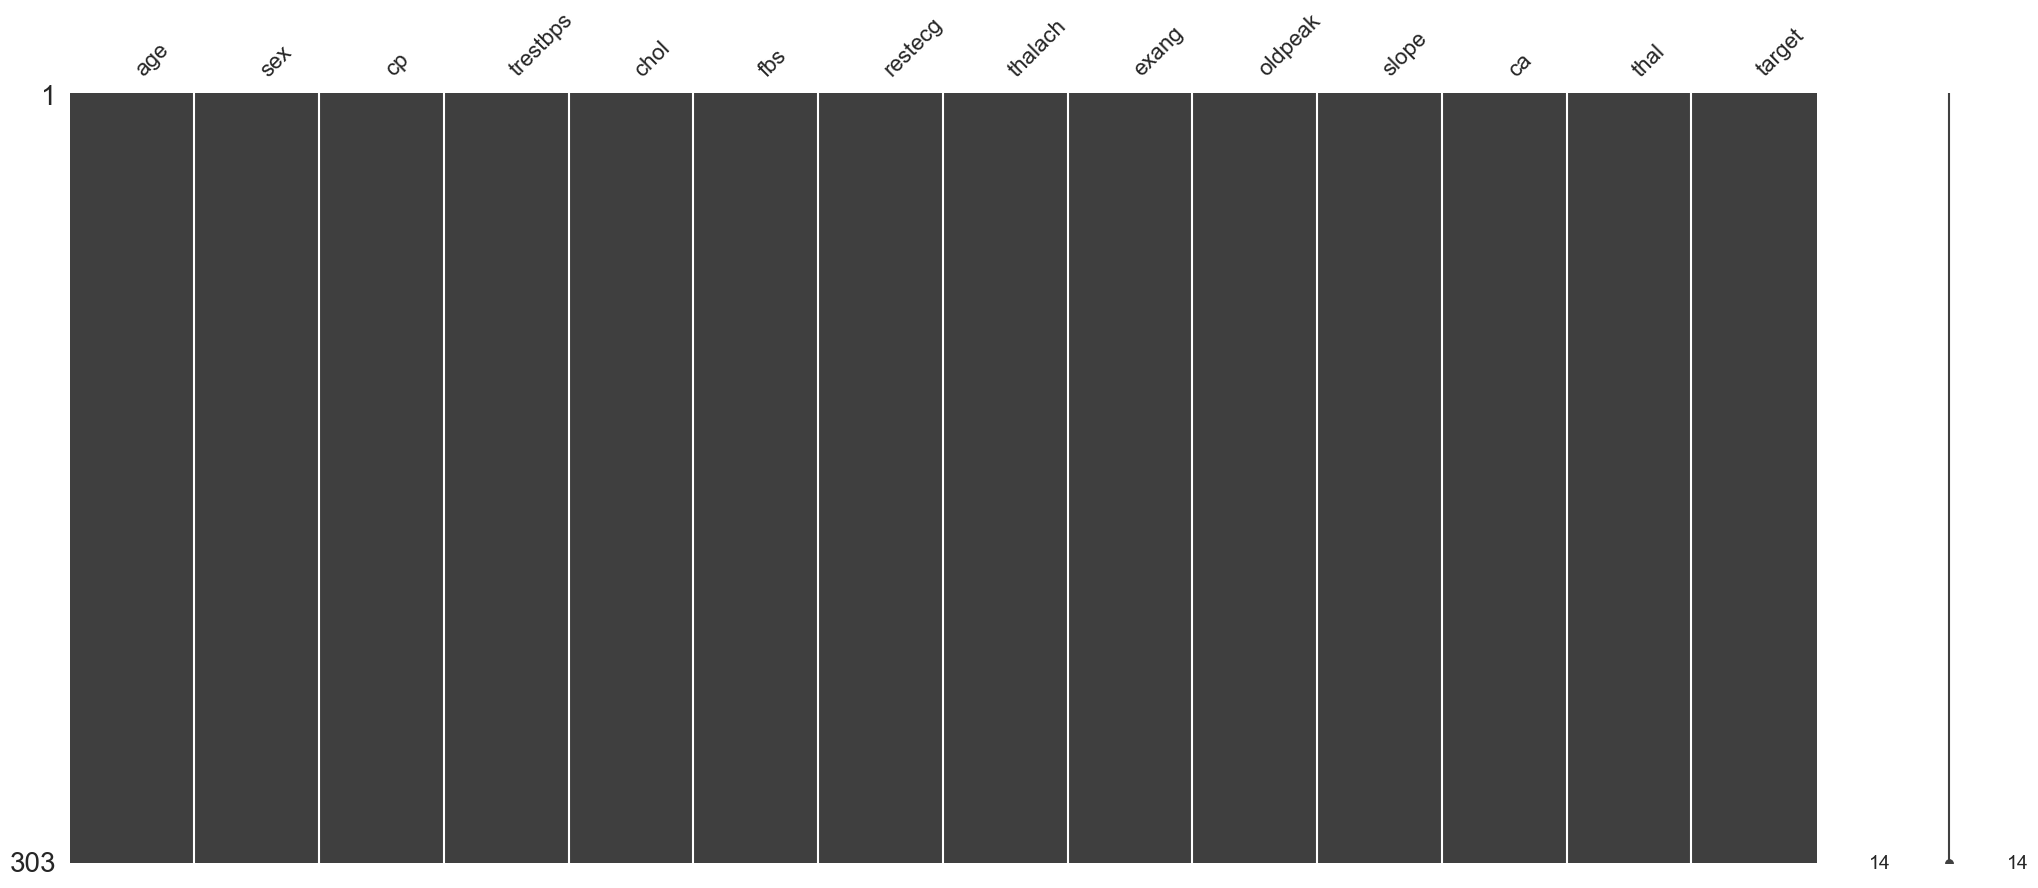

In [310]:
msno.matrix(df_heart_disease);

In [311]:
df_heart_disease.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [312]:
df_heart_disease.columns.duplicated().any()

False

In [313]:
df_heart_disease.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


***Consider rows with target = 1 or target = 0. Ignore other values***

In [314]:
df_heart_disease = df_heart_disease[(df_heart_disease['target'] == 1) | (df_heart_disease['target'] == 0)]
print(f"Dataset shape after filtering: {df_heart_disease.shape}")
df_heart_disease.describe()

Dataset shape after filtering: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


***Check outliers using Inter Quantile Range (IQR)***

We are not going to remove outliers since they carry valuable info about certain types of patients. However, it can give us an idea on the necessecity of the exploratory data analysis.

In [315]:
Q1 = df_heart_disease.quantile(0.95)
Q3 = df_heart_disease.quantile(0.1)
IQR = Q3 - Q1

In [316]:
Q1,Q3

(age          68.0
 sex           1.0
 cp            3.0
 trestbps    160.0
 chol        326.9
 fbs           1.0
 restecg       1.0
 thalach     181.9
 exang         1.0
 oldpeak       3.4
 slope         2.0
 ca            3.0
 thal          3.0
 target        1.0
 Name: 0.95, dtype: float64,
 age          42.0
 sex           0.0
 cp            0.0
 trestbps    110.0
 chol        188.0
 fbs           0.0
 restecg       0.0
 thalach     116.0
 exang         0.0
 oldpeak       0.0
 slope         1.0
 ca            0.0
 thal          2.0
 target        0.0
 Name: 0.1, dtype: float64)

In [317]:
IQR

age         -26.0
sex          -1.0
cp           -3.0
trestbps    -50.0
chol       -138.9
fbs          -1.0
restecg      -1.0
thalach     -65.9
exang        -1.0
oldpeak      -3.4
slope        -1.0
ca           -3.0
thal         -1.0
target       -1.0
dtype: float64

In [318]:
df_heart_disease_IQR = (df_heart_disease < (Q1 - 1.5 * IQR)) |(df_heart_disease > (Q3 + 1.5 * IQR))
df_heart_disease_IQR

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,True,True,True,True,True,True,True,True,True,True,True,True,True,True
299,True,True,True,True,True,True,True,True,True,True,True,True,True,True
300,True,True,True,True,True,True,True,True,True,True,True,True,True,True
301,True,True,True,True,True,True,True,True,True,True,True,True,True,True


***Drop Column which holds outlier***

In [319]:
Row_with_outliers = df_heart_disease_IQR.all(axis=0)
indx = Row_with_outliers[Row_with_outliers== False].index.to_list()
indx

[]

In [320]:
df_heart_disease = df_heart_disease.drop(indx, axis = 1)

In [321]:
df_heart_disease.reset_index(drop=True, inplace=True)

In [322]:
df_heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


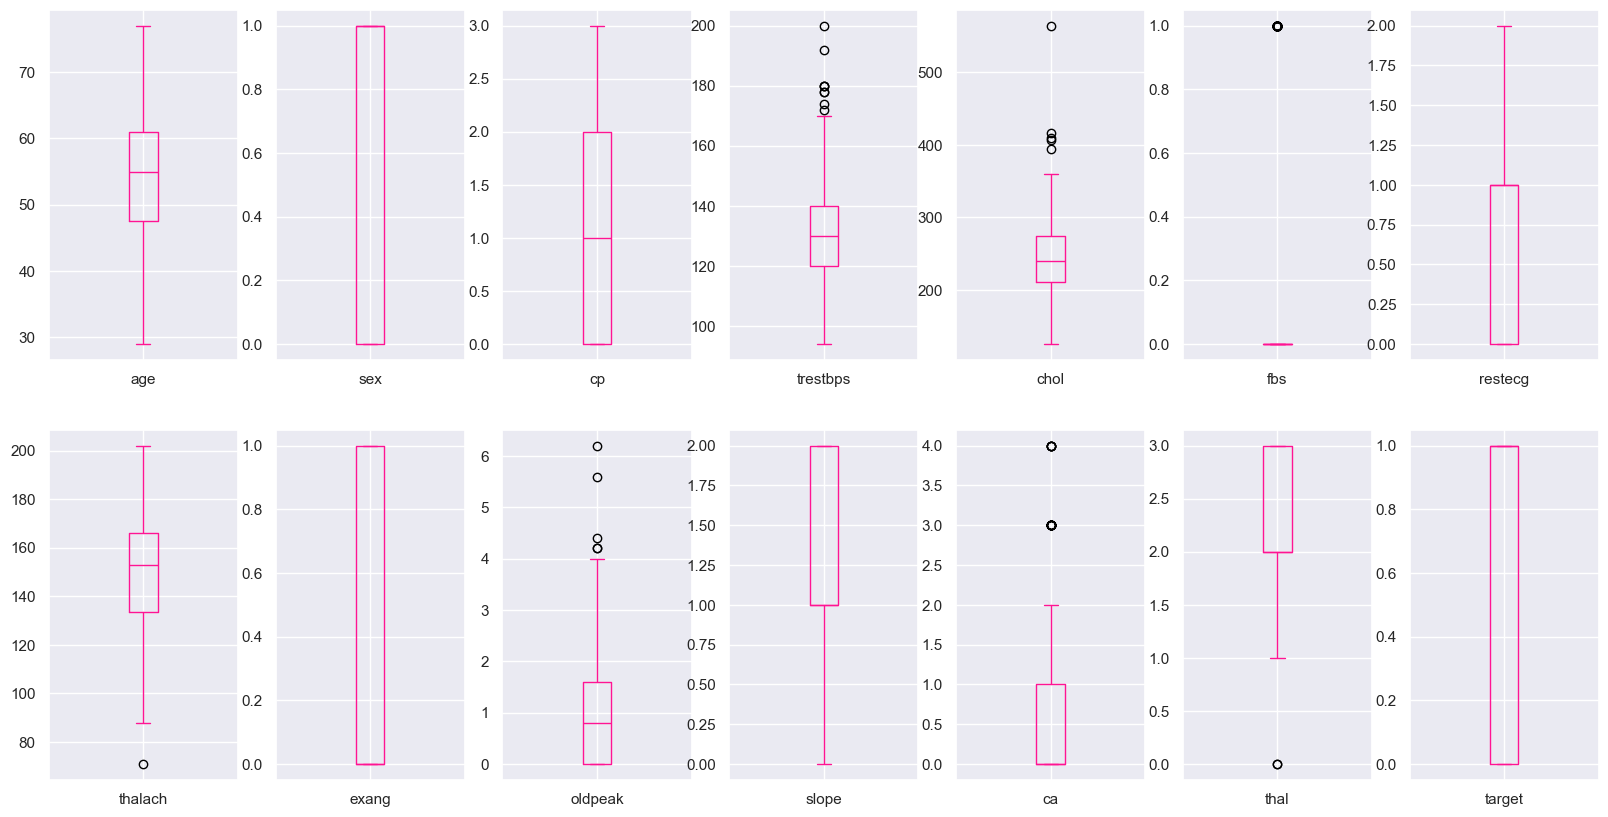

In [323]:
df_heart_disease.plot(kind='box', subplots=True, layout=(2,7),
sharex=False,sharey=False, figsize=(20, 10), 
color='deeppink');

In [324]:
df_heart_disease.describe()
#df_heart_disease.style.set_table_attributes('style="font-size: 10px"')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [325]:
def data_Sex(sex):
    if sex == 0:
        return 'female'
    else:
        return 'male'

def data_target(target):
    if target == 1:
        return 'With Heart Disease'
    else:
        return 'No Heart Disease'
    
def data_thal(thal):
    if thal == 0:
        return 'Non conclusive'
    elif thal == 2:
        return 'Normal'
    elif thal == 1:
        return 'Fixed Defect'
    else:
        return 'Reversible defect'

def data_cp(cp):
    if cp == 0:
        return 'Typical angina'
    elif cp == 1:
        return 'Atypical angina'
    elif cp== 2:
        return 'Non-anginal pain'
    else:
        return 'Asymptomatic'
    
def data_restecg(restecg):
    if restecg == 1:
        return 'Normal'
    elif restecg == 0:
        return 'left ventricular hypertrophy'
    else:
        return 'abnormality in ST-T wave'

def data_st_slope(slope):
    if slope == 0:
        return 'downsloping'
    elif slope == 1:
        return 'flat'
    else:
        return 'upsloping'

def data_age(age):
    if age < 30:
        return 'young patients'
    elif age >= 30 and age < 60:
        return 'middle aged patients'
    else:
        return 'elderly patients'
    
def data_chol(chol):
    if chol < 200:
        return 'Normal Cholesterol Level'
    else:
        return 'High Cholesterol Level'    

    
def data_trestbps(trestbps):
    if trestbps < 90:
        return 'Low Blood Pressure'
    elif trestbps >= 90 and trestbps <= 130:
        return 'Normal Blood Pressure'
    else:
        return 'High Blood Pressure'        
    
    
df_heart_disease_with_catagoricalData = df_heart_disease.copy()
df_heart_disease_with_catagoricalData['sex'] = df_heart_disease['sex'].apply(data_Sex)
df_heart_disease_with_catagoricalData['target'] = df_heart_disease['target'].apply(data_target)
df_heart_disease_with_catagoricalData['thal'] = df_heart_disease['thal'].apply(data_thal)
df_heart_disease_with_catagoricalData['cp'] = df_heart_disease['cp'].apply(data_cp)
df_heart_disease_with_catagoricalData['restecg'] = df_heart_disease['restecg'].apply(data_restecg)
df_heart_disease_with_catagoricalData['slope'] = df_heart_disease['slope'].apply(data_st_slope)
df_heart_disease_with_catagoricalData['age_class'] = df_heart_disease['age'].apply(data_age)
df_heart_disease_with_catagoricalData['chol_level'] = df_heart_disease['chol'].apply(data_chol)
df_heart_disease_with_catagoricalData['bp_level'] = df_heart_disease['trestbps'].apply(data_trestbps)

In [326]:
col_to_move = df_heart_disease_with_catagoricalData.pop('target')
df_heart_disease_with_catagoricalData.insert(len(df_heart_disease_with_catagoricalData.columns), 'target', col_to_move)

In [327]:
df_heart_disease_with_catagoricalData.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_class,chol_level,bp_level,target
0,63,male,Asymptomatic,145,233,1,left ventricular hypertrophy,150,0,2.3,downsloping,0,Fixed Defect,elderly patients,High Cholesterol Level,High Blood Pressure,With Heart Disease
1,37,male,Non-anginal pain,130,250,0,Normal,187,0,3.5,downsloping,0,Normal,middle aged patients,High Cholesterol Level,Normal Blood Pressure,With Heart Disease
2,41,female,Atypical angina,130,204,0,left ventricular hypertrophy,172,0,1.4,upsloping,0,Normal,middle aged patients,High Cholesterol Level,Normal Blood Pressure,With Heart Disease
3,56,male,Atypical angina,120,236,0,Normal,178,0,0.8,upsloping,0,Normal,middle aged patients,High Cholesterol Level,Normal Blood Pressure,With Heart Disease
4,57,female,Typical angina,120,354,0,Normal,163,1,0.6,upsloping,0,Normal,middle aged patients,High Cholesterol Level,Normal Blood Pressure,With Heart Disease


## **_Exploratory Data Analysis_**:

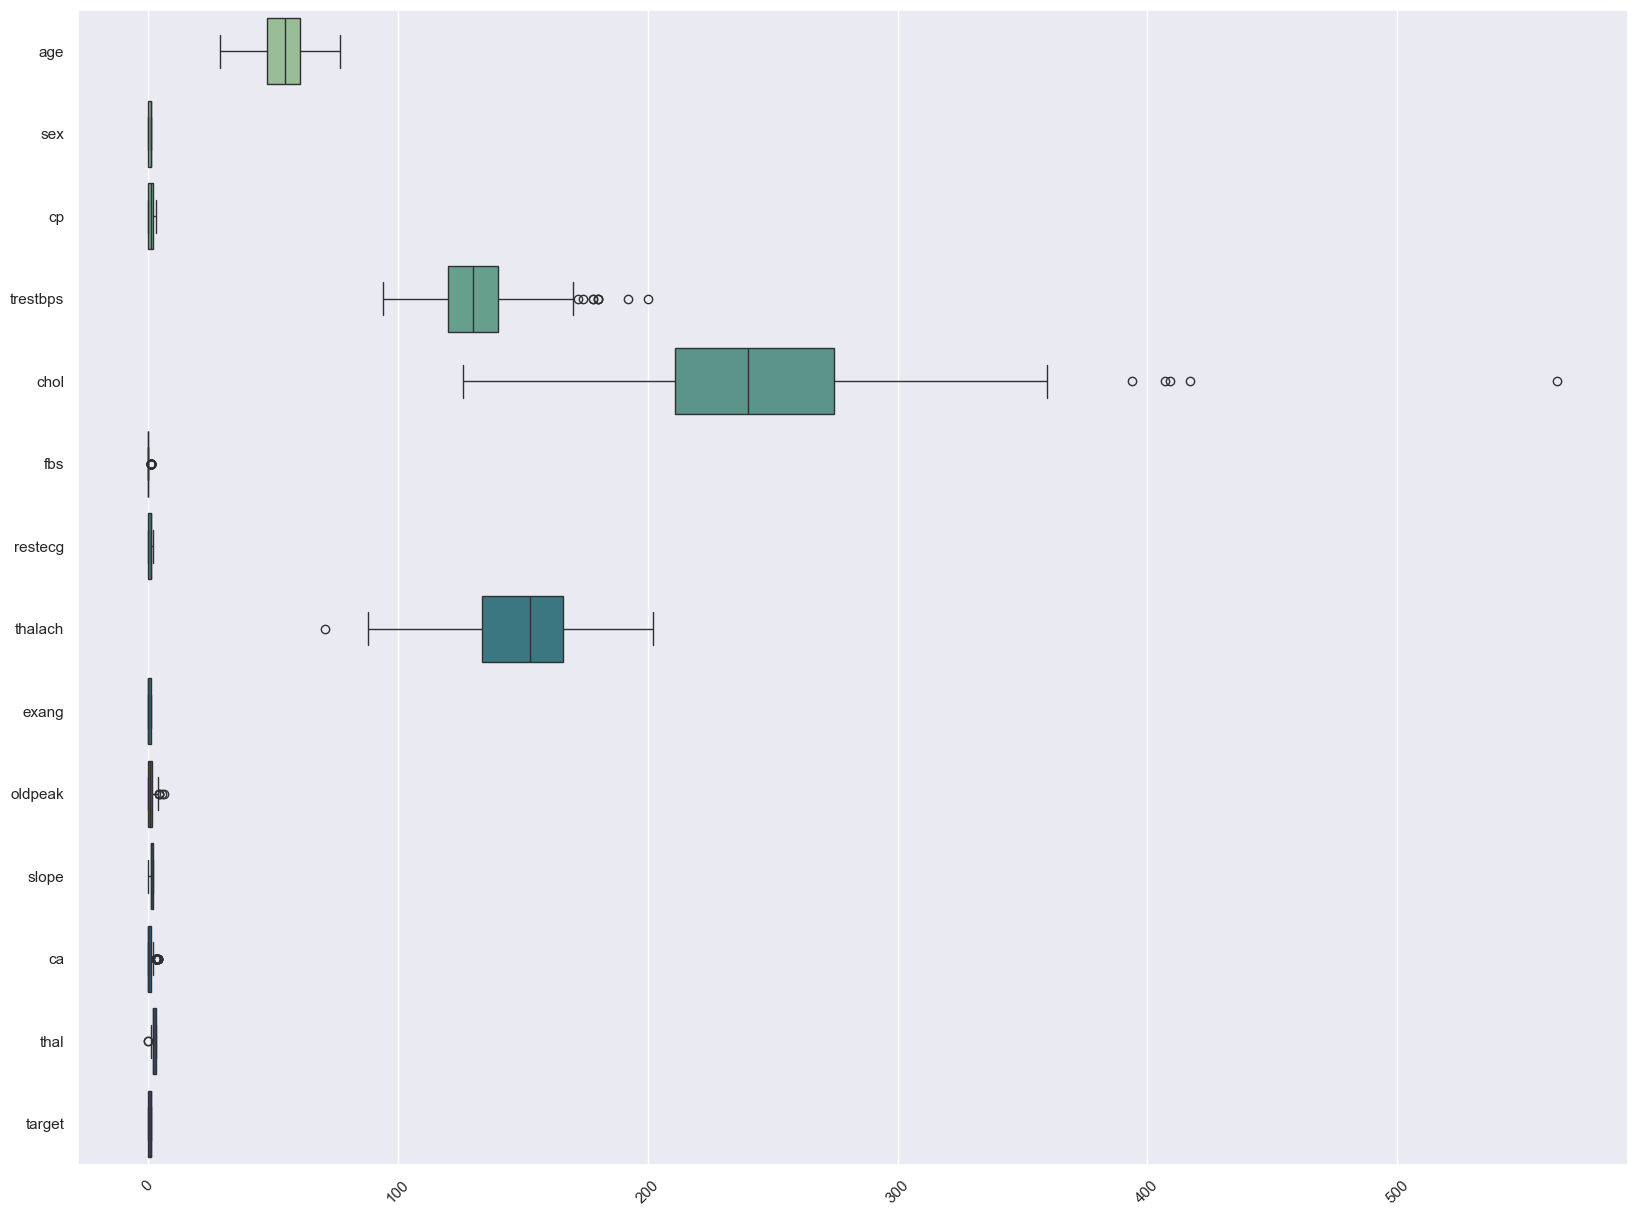

In [328]:
fig, out_fig = plt.subplots(figsize = (20,15))
plt.xticks(rotation=45)
out_fig = sns.boxplot(data = df_heart_disease, orient="h", palette="crest")

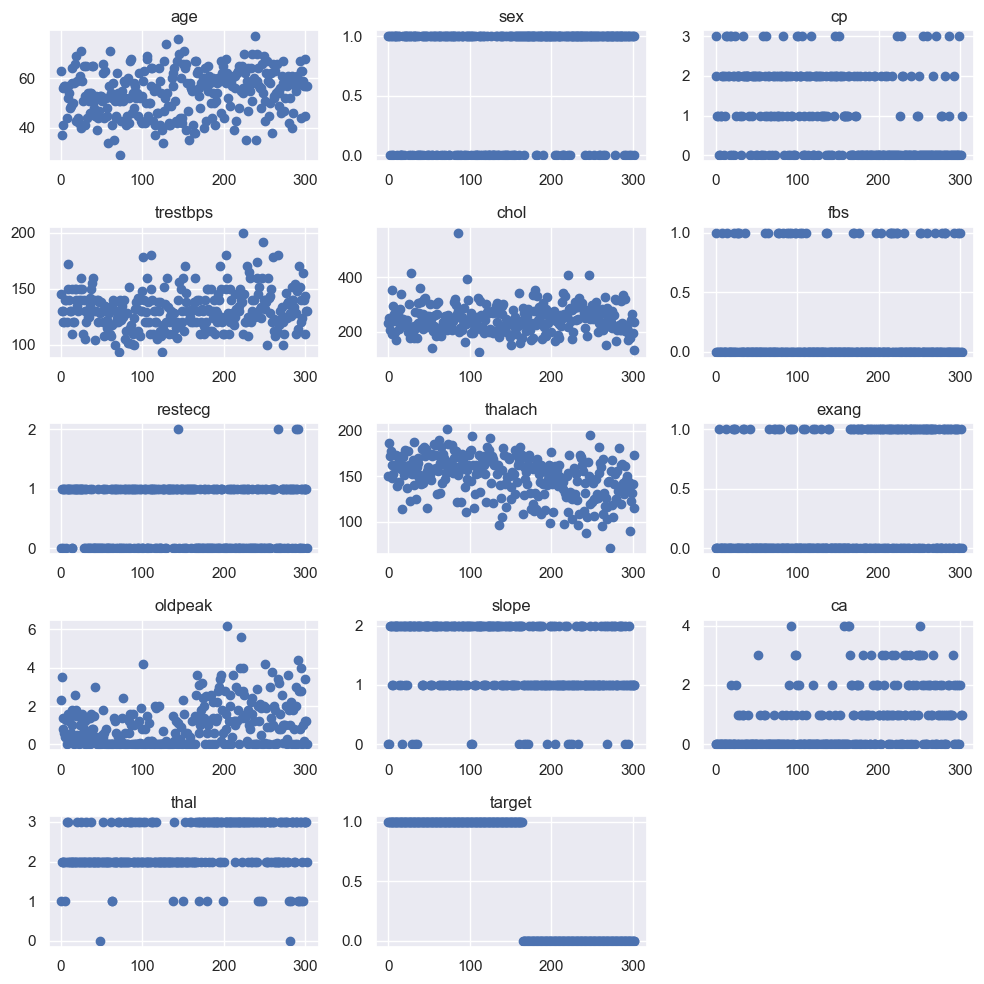

In [329]:
for i,col in enumerate(df_heart_disease.columns.values):
    plt.subplot(5,3,i+1)
    plt.scatter([i for i in range(303)],df_heart_disease[col].values.tolist())
    plt.title(col)
    fig,ax=plt.gcf(),plt.gca()
    fig.set_size_inches(10,10)
    plt.tight_layout()
plt.show()

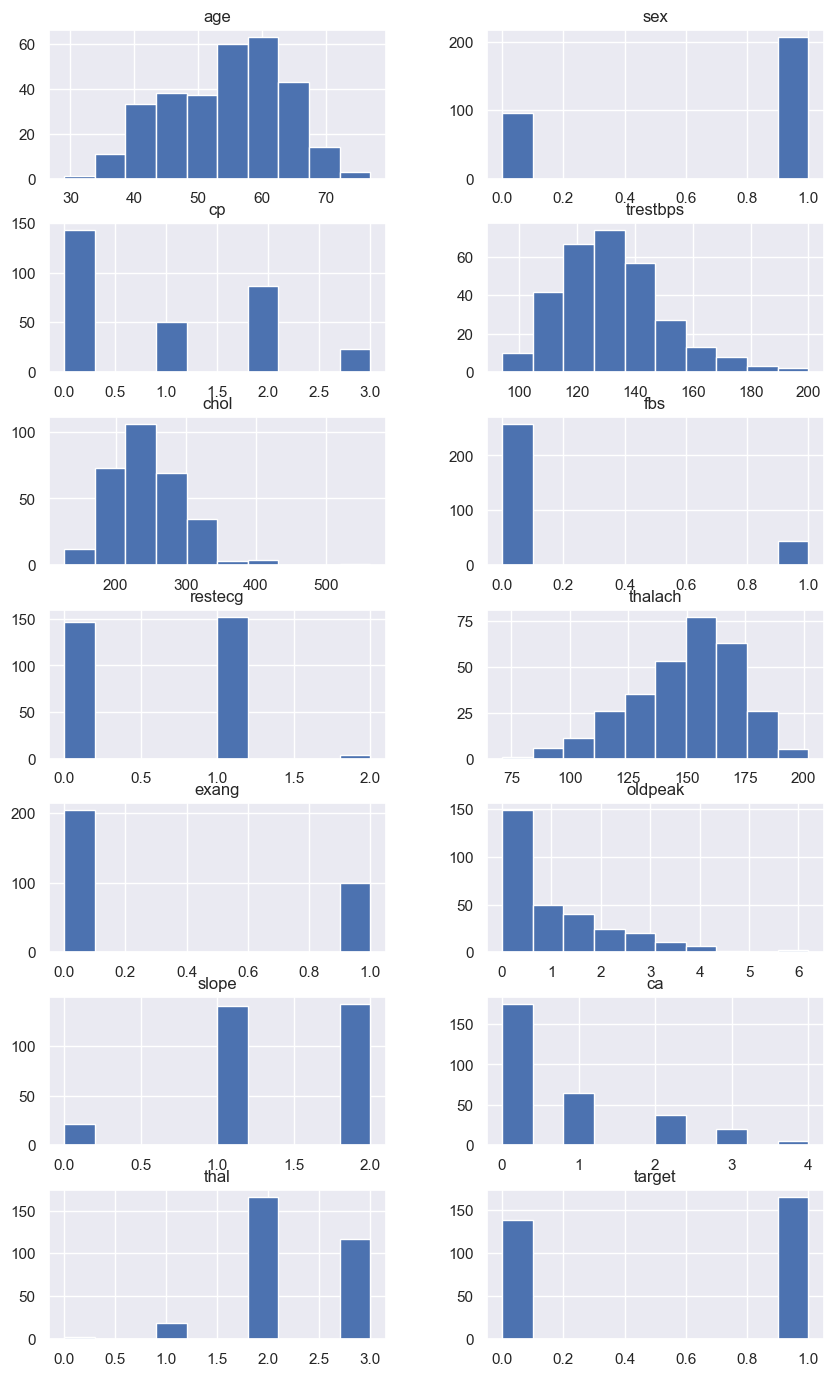

In [330]:
%matplotlib inline
fig, axis = plt.subplots(7,2,figsize=(10, 17));
df_heart_disease.hist(ax=axis);

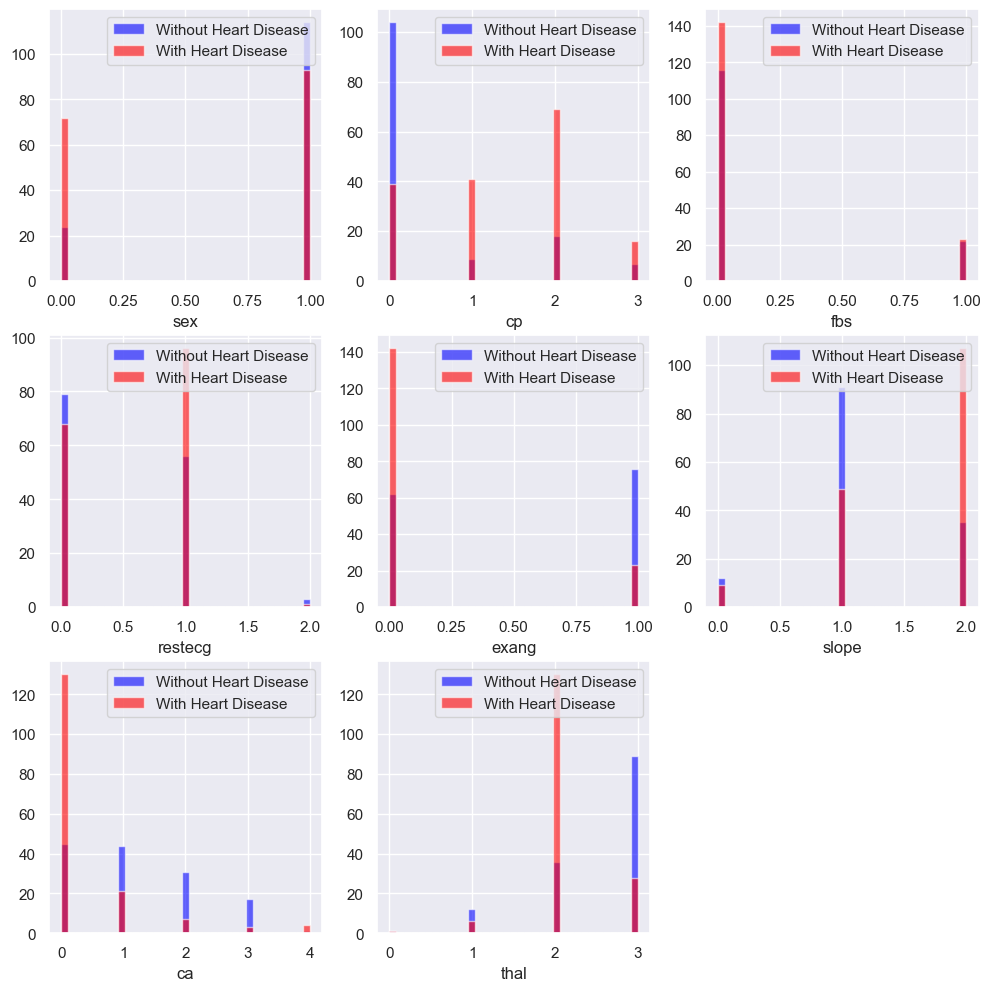

In [331]:
categorical_val = []
continous_val = []

for column in df_heart_disease.columns:
    if len(df_heart_disease[column].unique()) <= 15:
        categorical_val.append(column)
    else:
        continous_val.append(column)
        
plt.figure(figsize=(12, 12))
for i, column in enumerate(categorical_val[:-1], 1):
    plt.subplot(3, 3, i)
    df_heart_disease[df_heart_disease["target"] == 0][column].hist(bins=35, color='blue', label='Without Heart Disease', alpha=0.6)
    df_heart_disease[df_heart_disease["target"] == 1][column].hist(bins=35, color='red', label='With Heart Disease', alpha=0.6)
    plt.legend()
    plt.xlabel(column)
    plt.legend(loc='upper right');

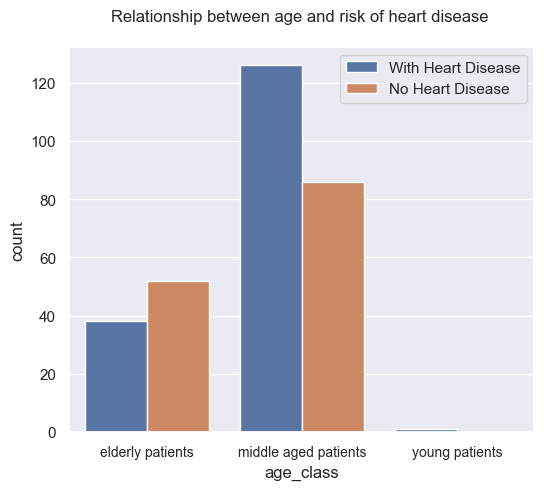

In [332]:
sns.set(rc={'figure.figsize':(6,5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData, x='age_class',hue='target')
plt.title('Relationship between age and risk of heart disease \n');
plt.legend(loc='upper right');

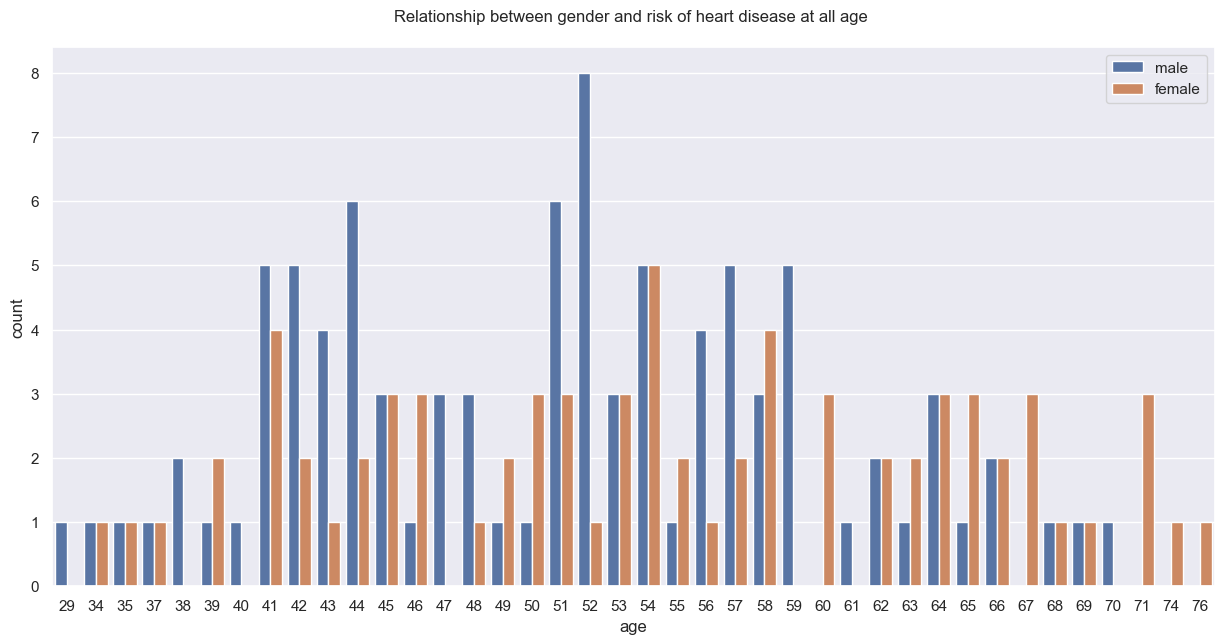

In [333]:
sns.set(rc={'figure.figsize':(15, 7)})
sns.countplot(data= df_heart_disease_with_catagoricalData[df_heart_disease_with_catagoricalData['target']=='With Heart Disease'], x='age',hue='sex')
plt.title('Relationship between gender and risk of heart disease at all age \n');
plt.legend(loc='upper right');

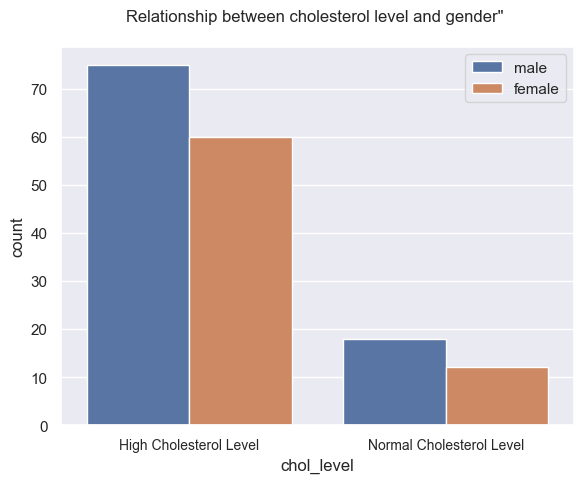

In [334]:
sns.set(rc={'figure.figsize':(6,5), 'xtick.labelsize':10})
plot_ = sns.countplot(data= df_heart_disease_with_catagoricalData[df_heart_disease_with_catagoricalData['target']=='With Heart Disease'], x='chol_level', hue='sex')
plt.title('Relationship between gender and risk of heart disease at all age with varying cholesterollevel \n');
plt.tight_layout();
plt.title('Relationship between cholesterol level and gender" \n');
plt.legend(loc='upper right');

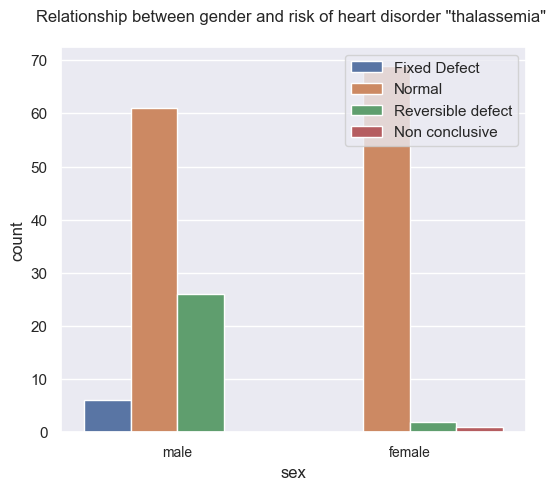

In [335]:
sns.set(rc={'figure.figsize':(6, 5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData[df_heart_disease_with_catagoricalData['target'] == 'With Heart Disease'], x='sex',hue='thal')
plt.title('Relationship between gender and risk of heart disorder "thalassemia" \n');
plt.legend(loc='upper right');

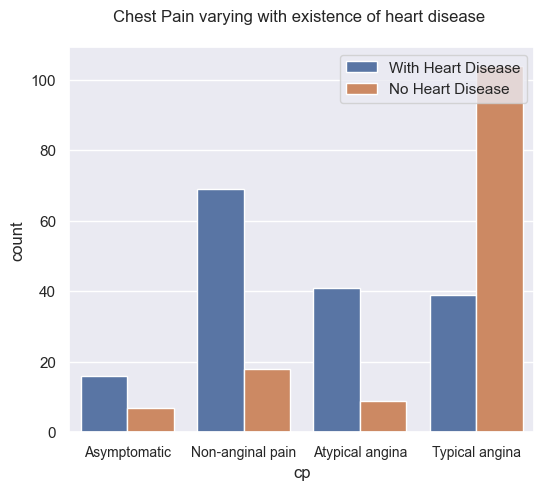

In [336]:
sns.set(rc={'figure.figsize':(6, 5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData, x='cp',hue='target')
plt.title('Chest Pain varying with existence of heart disease \n');
plt.legend(loc='upper right');

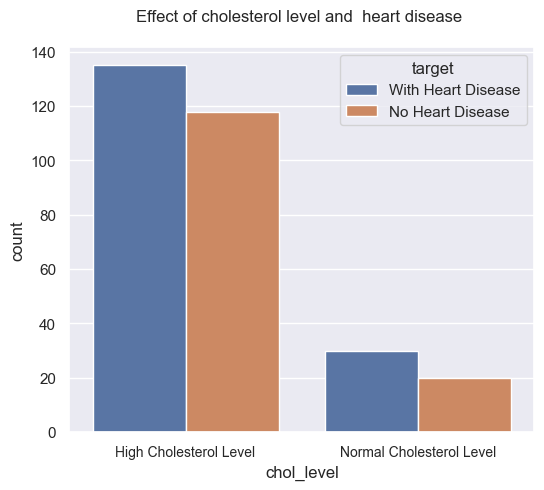

In [337]:
sns.set(rc={'figure.figsize':(6, 5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData, x='chol_level',hue='target')
plt.title('Effect of cholesterol level and  heart disease \n');

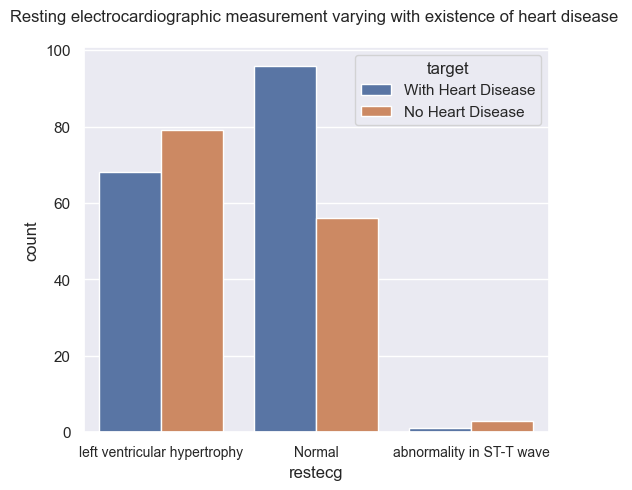

In [338]:
sns.countplot(data= df_heart_disease_with_catagoricalData, x='restecg',hue='target')
plt.title('Resting electrocardiographic measurement varying with existence of heart disease \n');

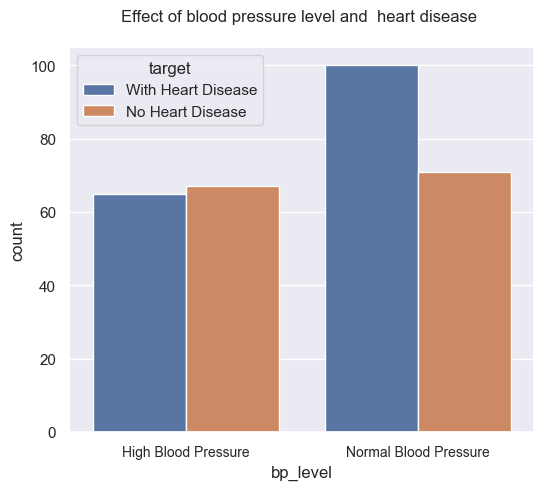

In [339]:
sns.set(rc={'figure.figsize':(6, 5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData, x='bp_level',hue='target')
plt.title('Effect of blood pressure level and  heart disease \n');

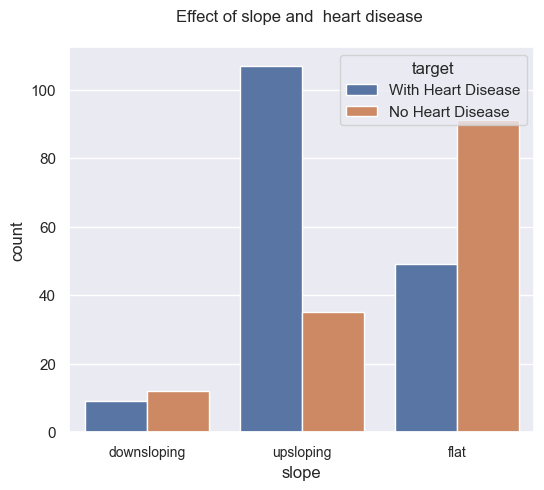

In [340]:
sns.set(rc={'figure.figsize':(6, 5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData, x='slope',hue='target')
plt.title('Effect of slope and  heart disease \n');

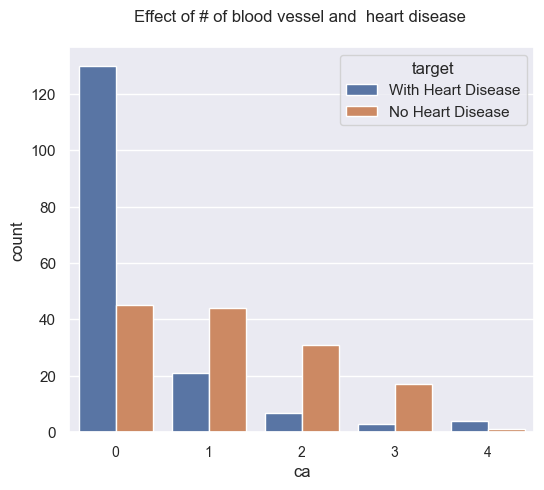

In [341]:
sns.set(rc={'figure.figsize':(6, 5), 'xtick.labelsize':10})
sns.countplot(data= df_heart_disease_with_catagoricalData, x='ca',hue='target')
plt.title('Effect of # of blood vessel and  heart disease \n');

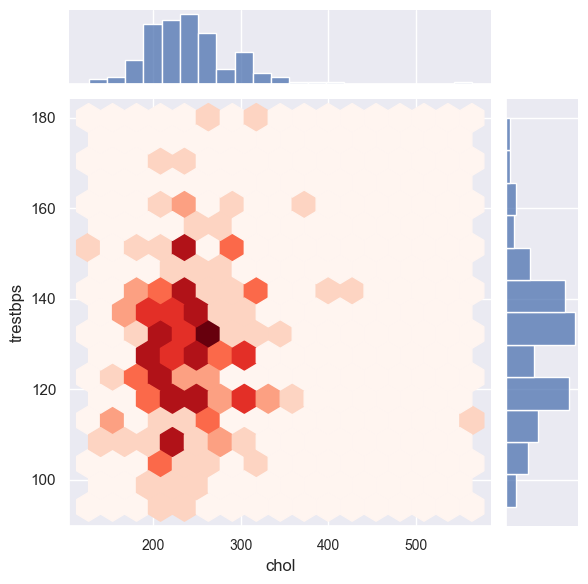

In [342]:
pal = sns.light_palette("blue", as_cmap=True)
sns.jointplot(data=df_heart_disease[df_heart_disease['target'] == 1],
              x='chol',
              y='trestbps',
              kind='hex',
              cmap='Reds');

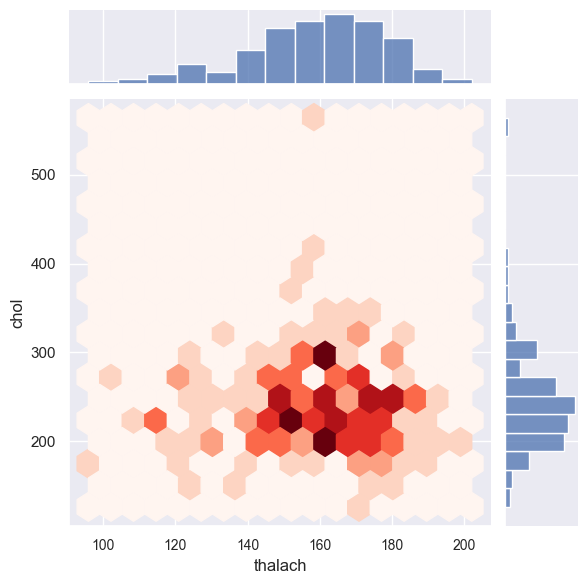

In [343]:
pal = sns.light_palette("blue", as_cmap=True)
sns.jointplot(data=df_heart_disease[df_heart_disease['target'] == 1],
              x='thalach',
              y='chol',
              kind='hex',
              cmap='Reds');

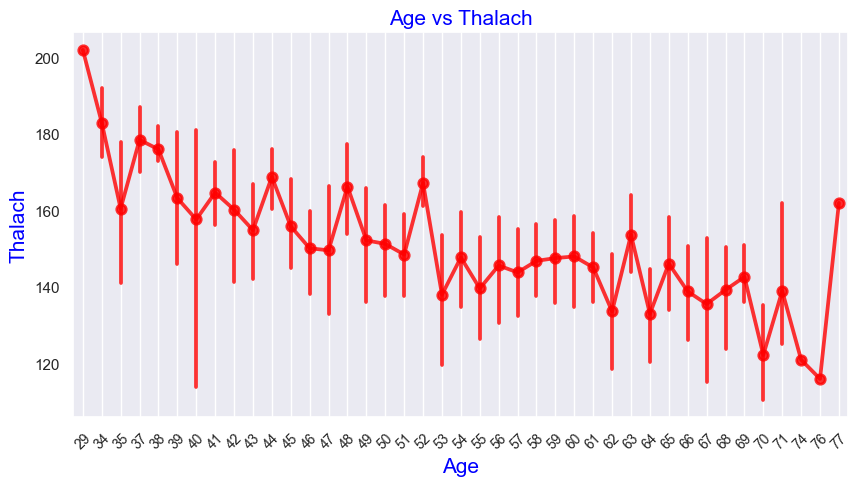

In [344]:
plt.figure(figsize=(10,5))
sns.pointplot(x=df_heart_disease['age'],y=df_heart_disease['thalach'],color='red',alpha=0.8)
plt.xlabel('Age',fontsize = 15,color='blue')
plt.xticks(rotation=45)
plt.ylabel('Thalach',fontsize = 15,color='blue')
plt.title('Age vs Thalach',fontsize = 15,color='blue')
plt.grid()
plt.show()

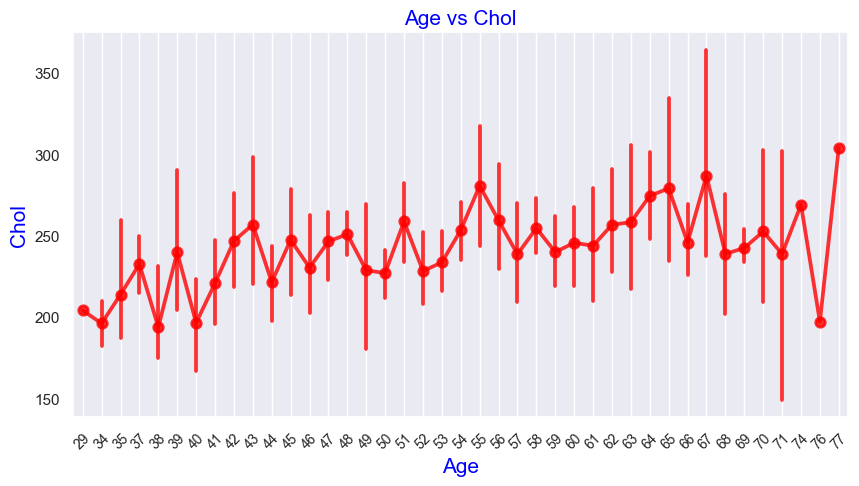

In [345]:
plt.figure(figsize=(10,5))
sns.pointplot(x=df_heart_disease['age'],y=df_heart_disease['chol'],color='red', alpha=0.8)
plt.xlabel('Age',fontsize = 15,color='blue')
plt.xticks(rotation=45)
plt.ylabel('Chol',fontsize = 15,color='blue')
plt.title('Age vs Chol',fontsize = 15,color='blue')
plt.grid()
plt.show()

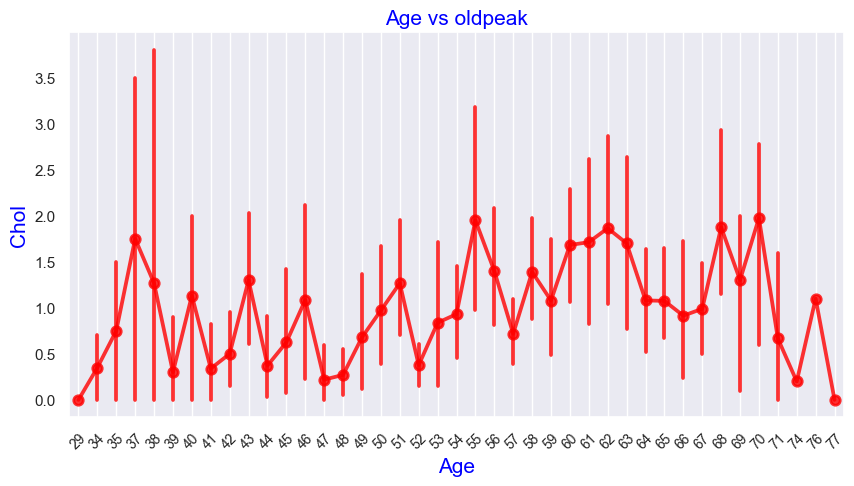

In [346]:
plt.figure(figsize=(10,5))
sns.pointplot(x=df_heart_disease['age'],y=df_heart_disease['oldpeak'],color='red', alpha=0.8)
plt.xlabel('Age',fontsize = 15,color='blue')
plt.xticks(rotation=45)
plt.ylabel('Chol',fontsize = 15,color='blue')
plt.title('Age vs oldpeak',fontsize = 15,color='blue')
plt.grid()
plt.show()

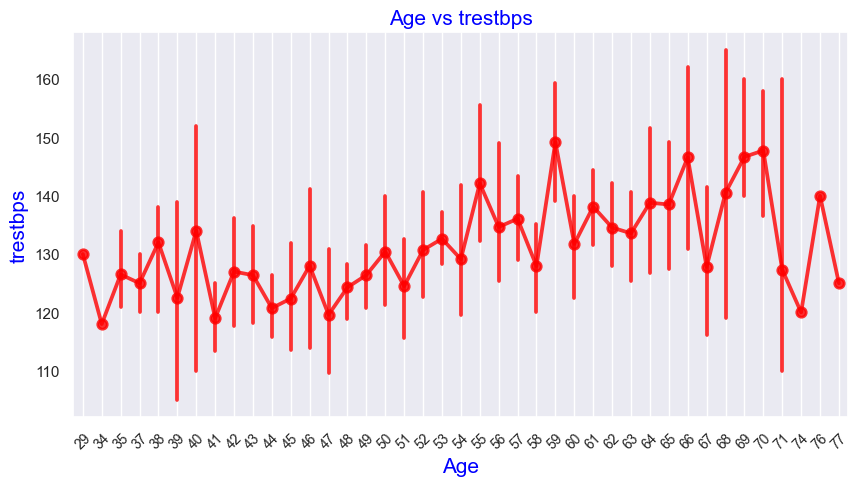

In [347]:
plt.figure(figsize=(10,5))
sns.pointplot(x=df_heart_disease['age'],y=df_heart_disease['trestbps'],color='red', alpha=0.8)
plt.xlabel('Age',fontsize = 15,color='blue')
plt.xticks(rotation=45)
plt.ylabel('trestbps',fontsize = 15,color='blue')
plt.title('Age vs trestbps',fontsize = 15,color='blue')
plt.grid()
plt.show()

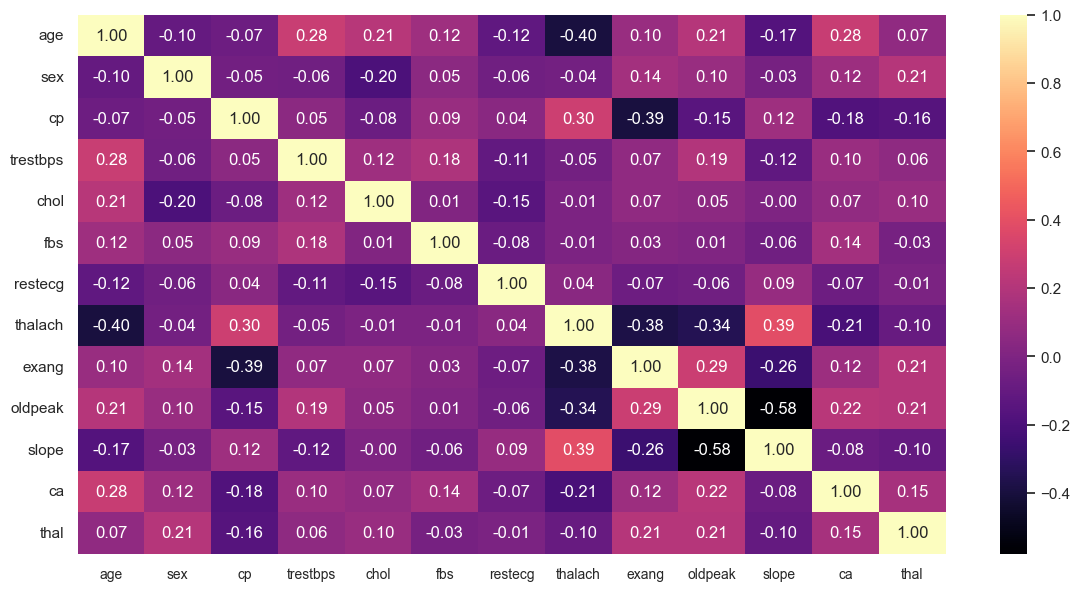

In [348]:
plt.figure(figsize=(14,7))
sns.heatmap(df_heart_disease.drop('target', axis=1).corr(),annot=True,cmap="magma",fmt='.2f');

In [349]:
import hvplot.pandas

df_heart_disease.drop('target', axis=1).corrwith(df_heart_disease.target).hvplot.barh(
    width=600, height=400, 
    title="Correlation between Heart Disease and Feature Vector", 
    ylabel='Correlation', xlabel='Feature Vector',
)

:Bars   [index]   (0)

### Features are not highly correlated. So it is reasonable to use these features to the machine learning model.

In [350]:
#Top  x% features to consider
fraction_of_top_features = 0.8

X = df_heart_disease.drop('target', axis=1)
y = df_heart_disease['target']
X_train, X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)

transformer = Normalizer()
X_train_scaled = transformer.fit_transform(X_train)
X_test_scaled = transformer.transform(X_test)

# *Important Feature Selection*:
### Univariate Feature Selection

In [351]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif
UV_model = SelectKBest(f_classif, k='all').fit(X_train_scaled, y_train)
mask = np.argsort(np.flip(UV_model.scores_)) #list of booleans for selected features
best_features_SKBest = [] 
best_features_SKBest = X_train.columns[mask]  

best_features_SKBest

Index(['thalach', 'oldpeak', 'restecg', 'thal', 'exang', 'ca', 'age', 'cp',
       'fbs', 'sex', 'slope', 'chol', 'trestbps'],
      dtype='object')

### Recursive feature elimination with Random Forest Classifier

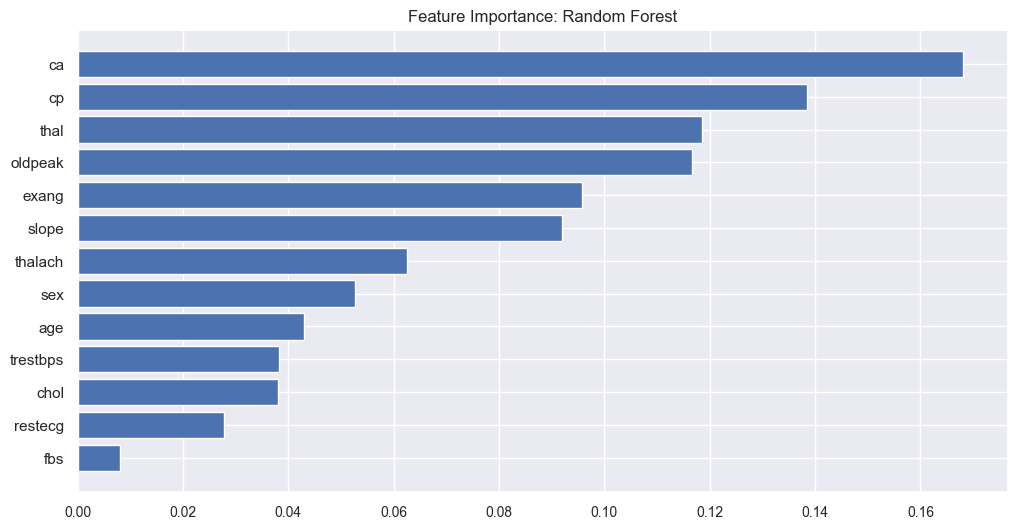

In [352]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

model_rf = RandomForestClassifier(n_estimators=1500, max_depth=5)
model_rf.fit(X_train_scaled, y_train)

feature_importance = model_rf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title('Feature Importance: Random Forest')

best_features_rf= X_train.columns[np.flip(sorted_idx)]
best_features_rf = best_features_rf[:int(fraction_of_top_features*len(best_features_rf))]

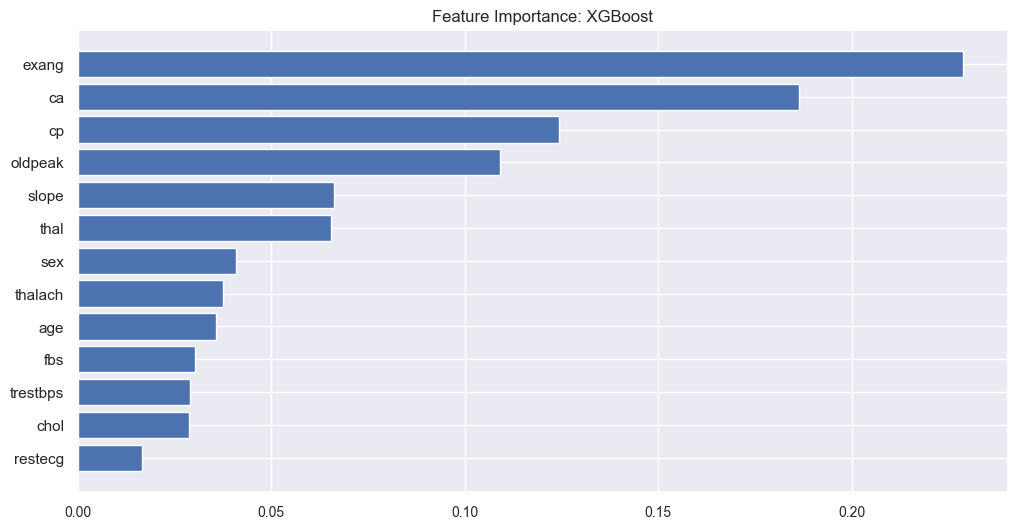

In [353]:
from sklearn.inspection import permutation_importance
import xgboost as xgb

model_xgb = xgb.XGBClassifier(n_estimators=1500, max_depth=5, eta=0.05)
model_xgb.fit(X_train_scaled, y_train)

feature_importance = model_xgb.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title('Feature Importance: XGBoost')

best_features_xgb = X_train.columns[np.flip(sorted_idx)]
best_features_xgb = best_features_xgb[:int(fraction_of_top_features*len(best_features_xgb))]

### Recursive feature elimination with XGBoost Classifier

In [354]:
best_feature_list = list(set.intersection(set(best_features_SKBest), set(best_features_rf), set(best_features_xgb)))
print("Best features selected:", best_feature_list)

Best features selected: ['age', 'cp', 'sex', 'slope', 'oldpeak', 'ca', 'thalach', 'thal', 'exang']


### Use PCA to see how many features are important:

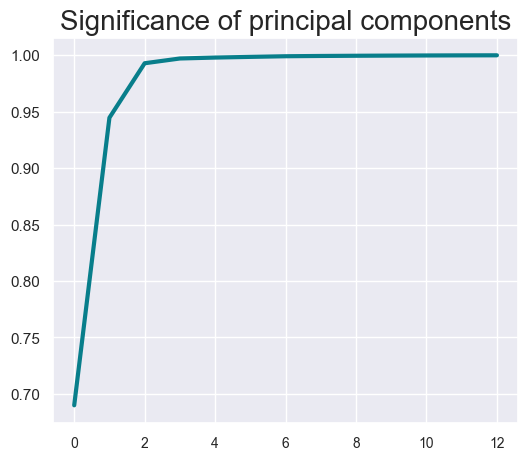

In [355]:
from sklearn.decomposition import PCA

pca = PCA(n_components = len(X_train.columns)).fit(X_train_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum(), lw=3, color='#087E8B')
plt.title('Significance of principal components', size=20)
plt.show()

Based on PCA seems like first 4 features are significant

### Best Feature Set:

In [356]:
best_feature_list

['age', 'cp', 'sex', 'slope', 'oldpeak', 'ca', 'thalach', 'thal', 'exang']

### Visualizing simple decision tree based classification using ***Best Feature Set***

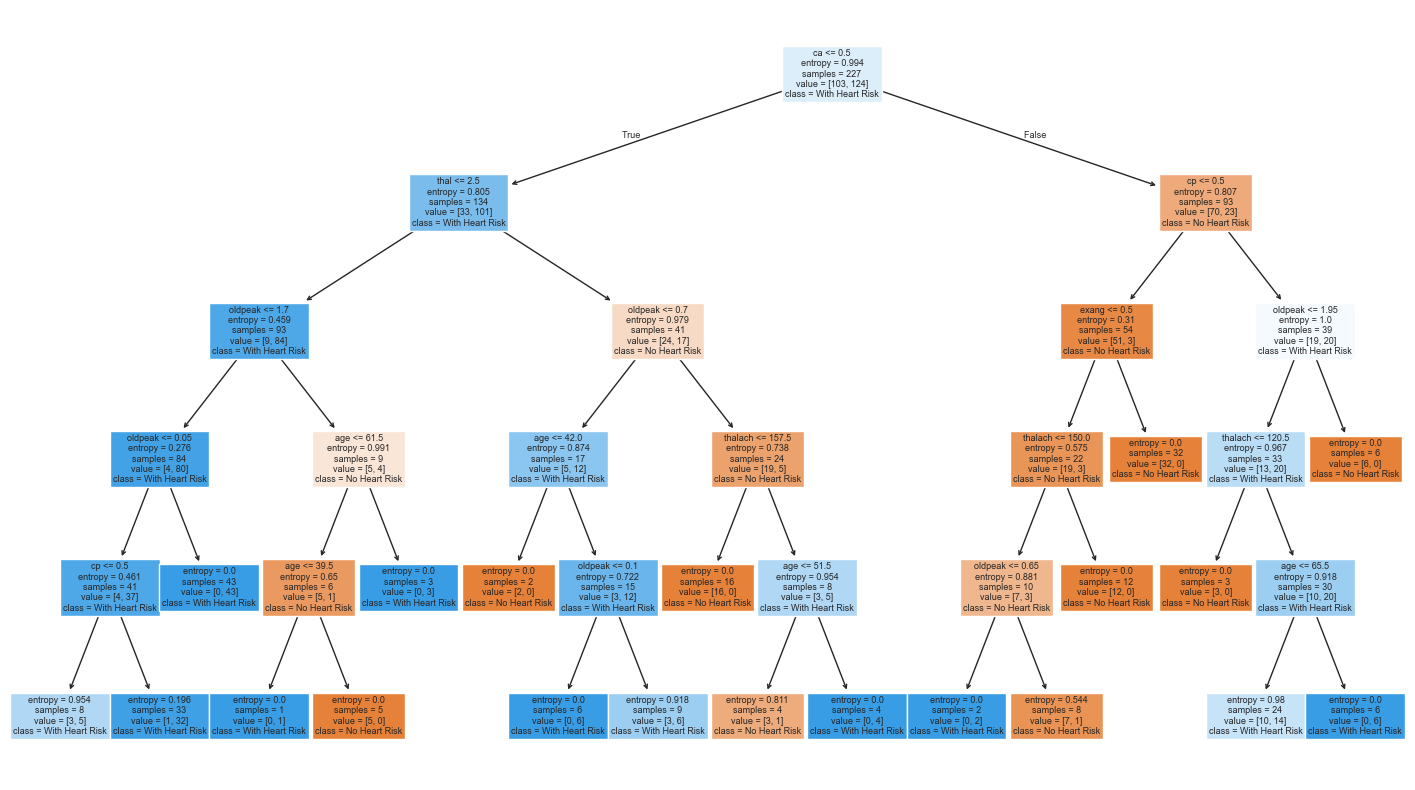

In [357]:
#Graphviz needs to be installed in the system to visualize the decision tree.

# from sklearn.tree import export_graphviz
# from six import StringIO 
# from IPython.display import Image  
# import pydotplus

# dot_data = StringIO()
# export_graphviz(clf, out_file=dot_data,  
#                 filled=False, rounded=True,
#                 special_characters=True,feature_names = X_train[best_feature_list].columns  ,class_names=['No Heart Risk','With Heart Risk'])
# graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
# Image(graph.create_png())

#Alternative way to visualize the decision tree without using graphviz.

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(criterion="entropy", max_depth=5)
clf = clf.fit(X_train[best_feature_list],y_train)

plt.figure(figsize=(18,10))
plot_tree(
    clf,
    feature_names=X_train[best_feature_list].columns,
    class_names=['No Heart Risk','With Heart Risk'],
    filled=True
)
plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')
plt.show()

# ML Model Development for heart risk detection

### Get a tuned model that has comparatively highest accuracy:
Use features with numerical values only ***df_heart_disease***

### Use extracted best features from these schemes. 
***best_feature_list***

In [358]:
X_train = X_train[best_feature_list]
X_test  = X_test[best_feature_list]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (227, 9)
X_test shape: (76, 9)


In [359]:
df_heart_disease = df_heart_disease[best_feature_list + ['target']]
print("Shape of df_heart_disease:", df_heart_disease.shape)

Shape of df_heart_disease: (303, 10)


In [360]:
ML_models = []
ML_Prediction_models = []

print(ML_models)
print(ML_Prediction_models)

[]
[]


## *XGBoost based classification for heart risk*

In [361]:
## Hyperparameter optimization using RandomizedSearchCV
import xgboost

In [362]:
#Initialize Model
clf_mdl = xgboost.XGBClassifier(use_label_encoder = False, verbosity = 1, eval_metric='logloss');

params = {
              'objective':['binary:logistic'],
              'learning_rate': [0.001, 0.005, 0.01, 0.1,0.3,0.5,0.7,1], 
              'max_depth': [1, 2, 3, 4, 5, 6, 7],
              'min_child_weight': [1e-5, 1e-3, 1e-2],
              'subsample': [0.01, 0.1, 0.3,0.5,0.7,1],
              'colsample_bytree': [0.7,1],
              'n_estimators': [100, 200, 300, 400, 500, 1000]
}
SEED = 42
#Initializing Grid Search with Stratified K Fold
xgb_ml = RandomizedSearchCV(clf_mdl, param_distributions=params, n_jobs=-1, cv=kfold, random_state=SEED)
xgb_ml.fit(X_train,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 1], 'learning_rate': [0.001, 0.005, ...], 'max_depth': [1, 2, ...], 'min_child_weight': [1e-05, 0.001, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [363]:
xgb_ml.best_params_

{'subsample': 0.7,
 'objective': 'binary:logistic',
 'n_estimators': 1000,
 'min_child_weight': 1e-05,
 'max_depth': 5,
 'learning_rate': 0.001,
 'colsample_bytree': 0.7}

In [364]:
Tuned_model_xgb = xgb_ml.best_estimator_
Tuned_model_xgb

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [365]:
prediction_xgb = Tuned_model_xgb.predict(X_test)

In [366]:
ML_models.append(Tuned_model_xgb)
ML_Prediction_models.append(prediction_xgb)

In [367]:
cm_xgb = confusion_matrix(y_test, prediction_xgb)

Confusion Matrix
confusion matrix:
[[27  8]
 [ 6 35]]


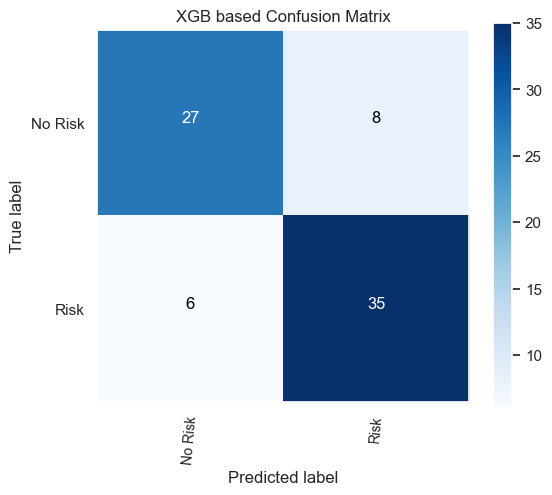

In [368]:
util.plot_confusion_matrix(cm_xgb,classes=['No Risk', 'Risk'], title='XGB based Confusion Matrix')

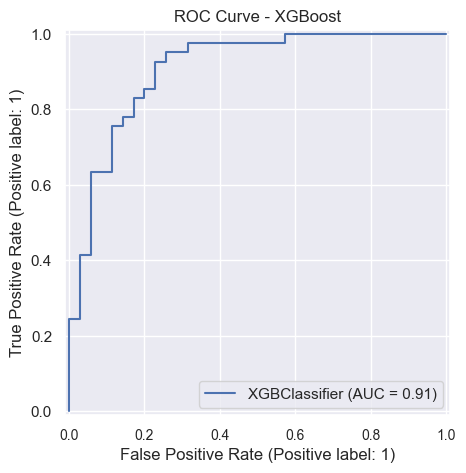

In [369]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    Tuned_model_xgb,
    X_test,
    y_test
)

plt.title("ROC Curve - XGBoost")
plt.show()

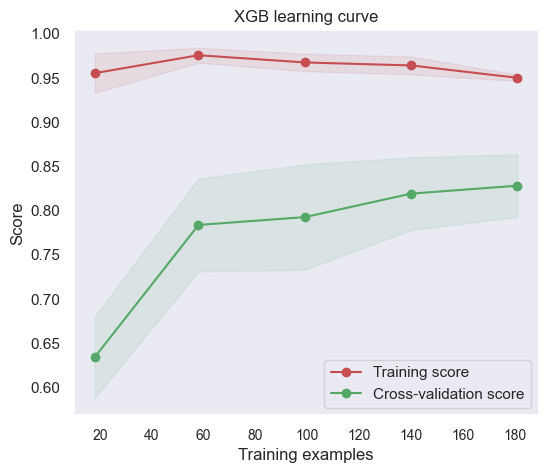

In [370]:
util.plot_learning_curve(estimator = Tuned_model_xgb, title = "XGB learning curve", X = X_train, y = y_train, cv = kfold);

## *Random Forest based classification for heart risk*

In [371]:
from sklearn.ensemble import RandomForestClassifier

In [372]:
#Initialize Model
clf_mdl_2 = RandomForestClassifier()

params = {'bootstrap': [True, False],
 'max_depth': range(1,10, 1),
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [100, 200, 300, 400, 500]}

#Initializing Grid Search with Stratified K Fold
rf_ml = RandomizedSearchCV(clf_mdl_2, param_distributions=params, n_jobs=-1, cv=kfold, random_state=SEED)
rf_ml.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_distributions,"{'bootstrap': [True, False], 'max_depth': range(1, 10), 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [373]:
rf_ml.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 4,
 'bootstrap': False}

In [374]:
Tuned_model_rf = rf_ml.best_estimator_
Tuned_model_rf

,n_estimators,200
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [375]:
prediction_rf = Tuned_model_rf.predict(X_test)

In [376]:
ML_models.append(Tuned_model_rf)
ML_Prediction_models.append(prediction_rf)

In [377]:
cm_rf = confusion_matrix(y_test, prediction_rf)

Confusion Matrix
confusion matrix:
[[27  8]
 [ 5 36]]


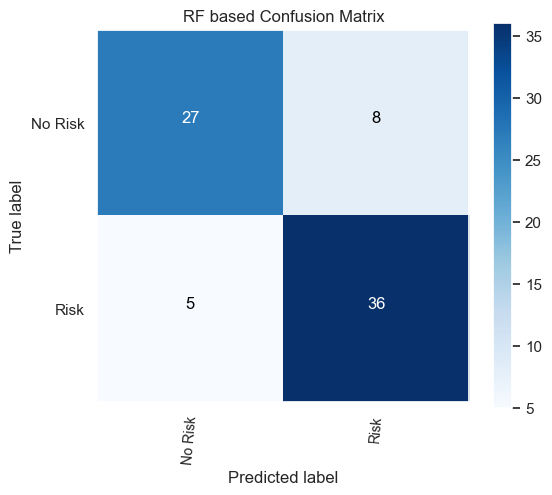

In [378]:
util.plot_confusion_matrix(cm_rf,classes=['No Risk', 'Risk'], title='RF based Confusion Matrix')

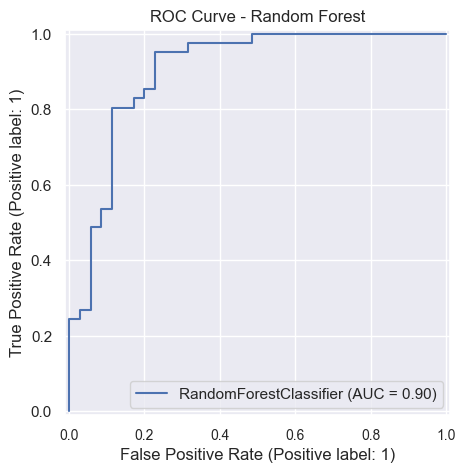

In [379]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    Tuned_model_rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

<module 'matplotlib.pyplot' from 'c:\\Users\\suhas.kumar.regeti\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

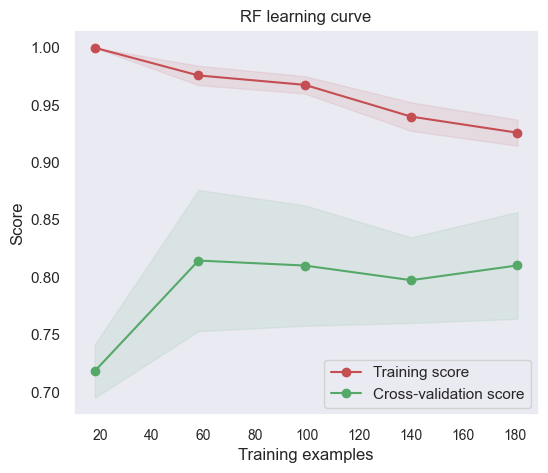

In [380]:
util.plot_learning_curve(estimator = Tuned_model_rf, title = "RF learning curve", X = X_train, y = y_train, cv = kfold)

## *Logistic Regression based classification for heart risk*

In [381]:
from sklearn.linear_model import LogisticRegression

In [382]:
#Initialize Model
clf_mdl_3 = LogisticRegression()

params = {
    "max_iter": range(100,500,2),
    "solver" : ['newton-cg', 'lbfgs', 'liblinear'],
    "C": [0.5, 0.1, 1.0]
}

lgr_ml = RandomizedSearchCV(clf_mdl_3, param_distributions=params, n_jobs=-1, cv=kfold, random_state=SEED)
lgr_ml.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_distributions,"{'C': [0.5, 0.1, ...], 'max_iter': range(100, 500, 2), 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [383]:
lgr_ml.best_params_

{'solver': 'lbfgs', 'max_iter': 180, 'C': 0.5}

In [384]:
Tuned_model_lgr = lgr_ml.best_estimator_
Tuned_model_lgr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,180
,multi_class,'deprecated'


In [385]:
prediction_lgr = Tuned_model_lgr.predict(X_test)

In [386]:
ML_models.append(Tuned_model_lgr)
ML_Prediction_models.append(prediction_lgr)

In [387]:
cm_lgr = confusion_matrix(y_test, prediction_lgr)

Confusion Matrix
confusion matrix:
[[30  5]
 [ 4 37]]


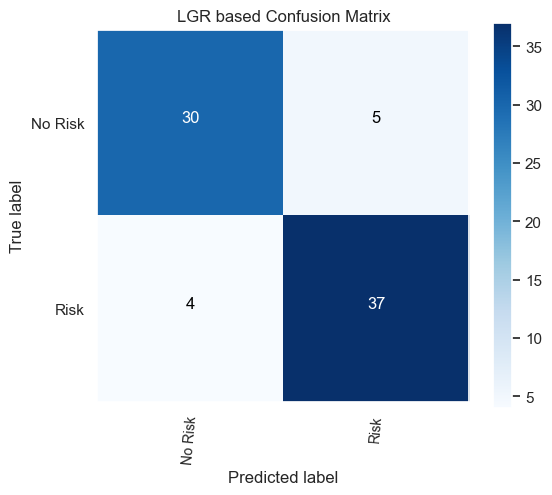

In [388]:
util.plot_confusion_matrix(cm_lgr,classes=['No Risk', 'Risk'], title='LGR based Confusion Matrix')

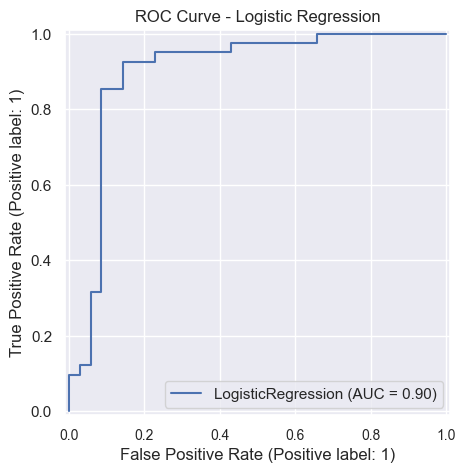

In [389]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    Tuned_model_lgr,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

<module 'matplotlib.pyplot' from 'c:\\Users\\suhas.kumar.regeti\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

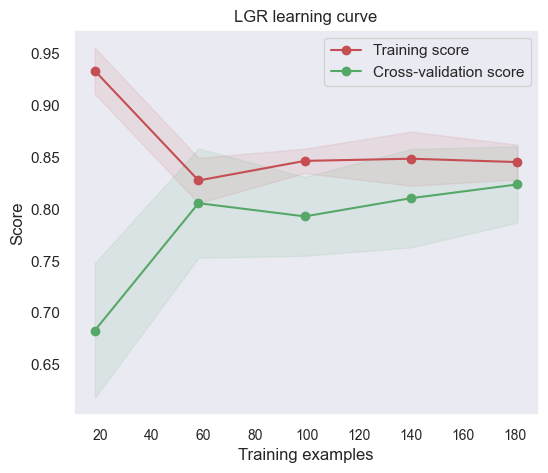

In [390]:
util.plot_learning_curve(estimator = Tuned_model_lgr, title = "LGR learning curve", X = X_train, y = y_train, cv = kfold)

## *LightGBM based classification for heart risk*

In [391]:
## Hyperparameter optimization using RandomizedSearchCV
import lightgbm as lgb

In [392]:
#Initialize Model
clf_mdl_4 = lgb.LGBMClassifier();

params = {'num_leaves':range(10,100, 10), 'min_child_samples':range(5,25,5),'max_depth': range(5, 15, 1),
             'learning_rate':[0.05,0.1,0.2],'reg_alpha': [0,0.01,0.03]}

#Initializing Grid Search with Stratified K Fold
lgb_ml = RandomizedSearchCV(clf_mdl_4, param_distributions=params, n_jobs=-1, cv=kfold, random_state=SEED)
lgb_ml.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 124, number of negative: 103
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 129
[LightGBM] [Info] Number of data points in the train set: 227, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546256 -> initscore=0.185553
[LightGBM] [Info] Start training from score 0.185553
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,estimator,LGBMClassifier()
,param_distributions,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': range(5, 15), 'min_child_samples': range(5, 25, 5), 'num_leaves': range(10, 100, 10), ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [393]:
lgb_ml.best_params_

{'reg_alpha': 0.03,
 'num_leaves': 50,
 'min_child_samples': 15,
 'max_depth': 13,
 'learning_rate': 0.2}

In [394]:
Tuned_model_lgb = lgb_ml.best_estimator_
Tuned_model_lgb

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,13
,learning_rate,0.2
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,15


In [395]:
prediction_lgb = Tuned_model_lgb.predict(X_test)

In [396]:
cm_lgb = confusion_matrix(y_test, prediction_lgb)

In [397]:
ML_models.append(Tuned_model_lgb)
ML_Prediction_models.append(prediction_lgb)

Confusion Matrix
confusion matrix:
[[27  8]
 [ 7 34]]


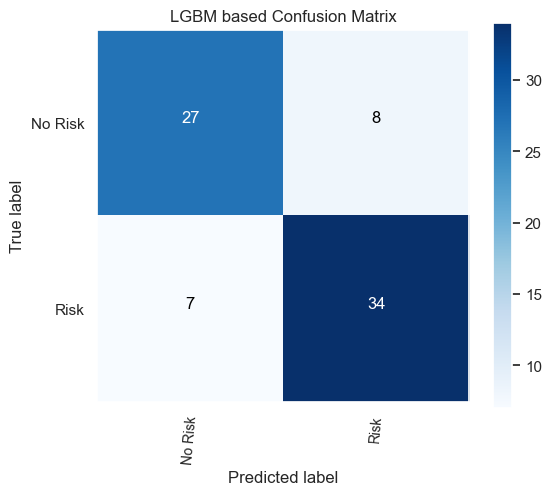

In [398]:
util.plot_confusion_matrix(cm_lgb,classes=['No Risk', 'Risk'], title='LGBM based Confusion Matrix')

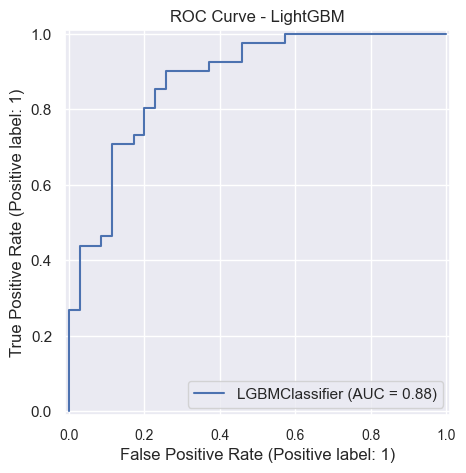

In [399]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    Tuned_model_lgb,
    X_test,
    y_test
)

plt.title("ROC Curve - LightGBM")
plt.show()

<module 'matplotlib.pyplot' from 'c:\\Users\\suhas.kumar.regeti\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

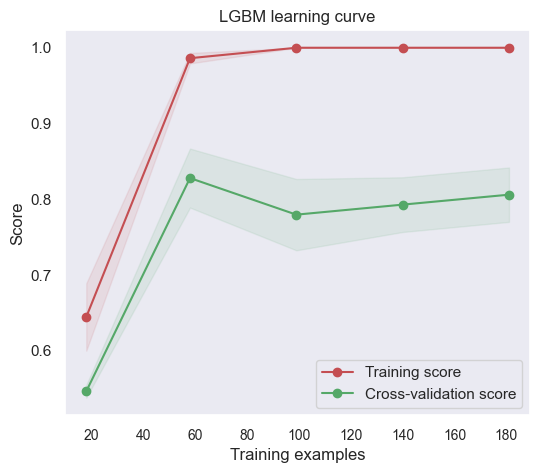

In [400]:
util.plot_learning_curve(estimator = Tuned_model_lgb, title = "LGBM learning curve", X = X_train, y = y_train, cv = kfold)

## *Linear Discriminant Analysis based classification for heart risk*

In [401]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [402]:
#Initialize Model
clf_mdl_5 = LinearDiscriminantAnalysis()

params = {
    "solver" : ["svd"],
     "tol" : [0.0001,0.0002,0.0003]
}

lda_ml = RandomizedSearchCV(clf_mdl_5, param_distributions=params, n_jobs=-1, cv=kfold, random_state=SEED)
lda_ml.fit(X_train,y_train)

,estimator,LinearDiscriminantAnalysis()
,param_distributions,"{'solver': ['svd'], 'tol': [0.0001, 0.0002, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [403]:
lda_ml.best_params_

{'tol': 0.0001, 'solver': 'svd'}

In [404]:
Tuned_model_lda = lda_ml.best_estimator_
Tuned_model_lda

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [405]:
prediction_lda = Tuned_model_lda.predict(X_test)

In [406]:
ML_models.append(Tuned_model_lda)
ML_Prediction_models.append(prediction_lda)

In [407]:
cm_lda = confusion_matrix(y_test, prediction_lda) 

Confusion Matrix
confusion matrix:
[[29  6]
 [ 4 37]]


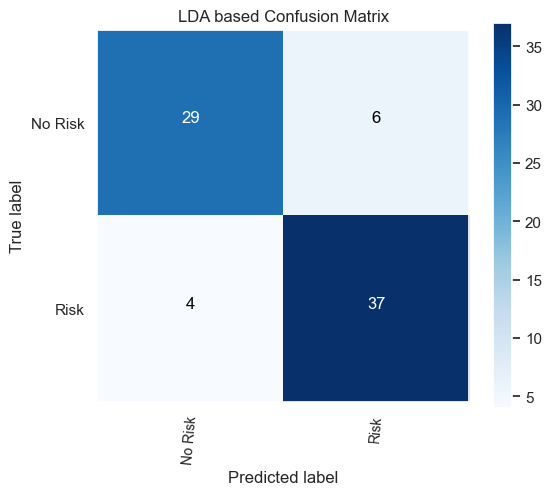

In [408]:
util.plot_confusion_matrix(cm_lda,classes=['No Risk', 'Risk'], title='LDA based Confusion Matrix')

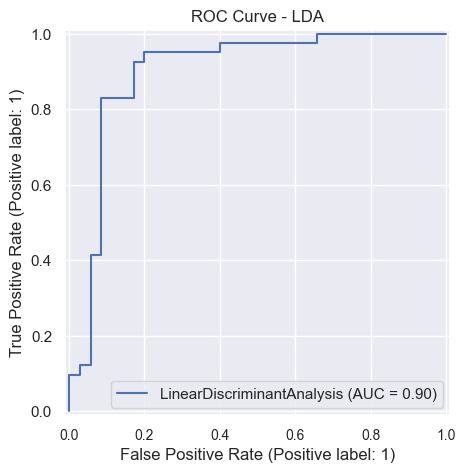

In [409]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    Tuned_model_lda,
    X_test,
    y_test
)

plt.title("ROC Curve - LDA")
plt.show()

<module 'matplotlib.pyplot' from 'c:\\Users\\suhas.kumar.regeti\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

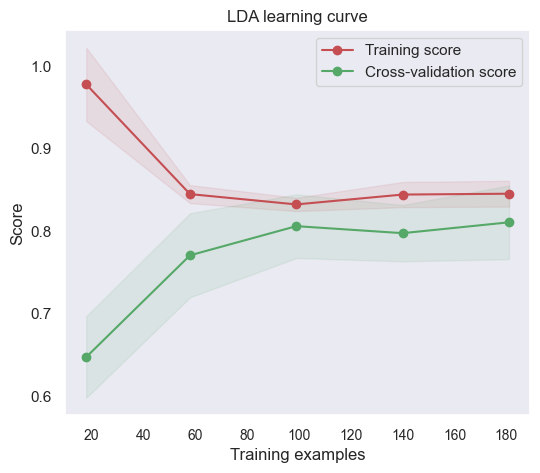

In [410]:
util.plot_learning_curve(estimator = Tuned_model_lda, title = "LDA learning curve", X = X_train, y = y_train, cv = kfold)

## *Ensemble learning based classification for heart risk*

In [411]:
from sklearn.ensemble import VotingClassifier

In [412]:
VotingPredictor = VotingClassifier(estimators =
                           [('rfc', Tuned_model_rf), 
                            ('lgr', Tuned_model_lgr), 
                            ('lda', Tuned_model_lda),
                            ('xgb', Tuned_model_xgb),
                            ('lgb', Tuned_model_lgb)],
                           voting='soft', n_jobs = -1)


VotingPredictor = VotingPredictor.fit(X_train, y_train);

In [413]:
prediction_vp = VotingPredictor.predict(X_test)

In [414]:
ML_models.append(VotingPredictor)
ML_Prediction_models.append(prediction_vp)

In [415]:
cm_vp = confusion_matrix(y_test, prediction_vp)

Confusion Matrix
confusion matrix:
[[27  8]
 [ 4 37]]


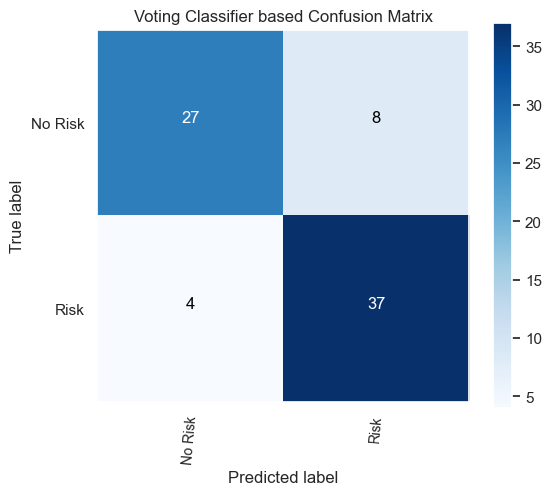

In [416]:
util.plot_confusion_matrix(cm_vp,classes=['No Risk', 'Risk'], title='Voting Classifier based Confusion Matrix')

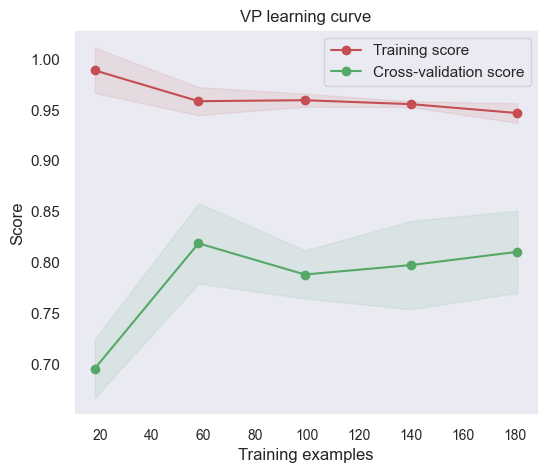

In [417]:
util.plot_learning_curve(estimator = VotingPredictor, title = "VP learning curve",
                    X = X_train, y = y_train, cv = kfold);

In [418]:
Metrics_df = pd.DataFrame()

data_dict = {}

model_name = []
model_metrics = []

for item in enumerate(ML_models):
    y_pred = ML_Prediction_models[item[0]]
    recall_scr = recall_score(y_test, y_pred)
    f1_scr = f1_score(y_test, y_pred)   
    precision_scr = precision_score(y_test, y_pred) 
    accuracy_scr = accuracy_score(y_test, y_pred)
    y_prob = ML_models[item[0]].predict_proba(X_test)[:,0]
    roc_auc_scr = roc_auc_score(y_test, y_prob)   
    cross_val_scr = cross_val_score(ML_models[item[0]], X_train, y_train,cv=10, n_jobs = -1, scoring = 'accuracy').mean()
    model_name.append(type(ML_models[item[0]]).__name__)
    model_metrics.append([recall_scr, f1_scr, precision_scr, accuracy_scr, roc_auc_scr, cross_val_scr])


for i in range(len(model_name)):
    data_dict[model_name[i]] = model_metrics[i]


In [419]:
metrics_name = ['recall', 'f1', 'precision','accuracy', 'roc_auc', 'cross_validation']
Metrics_df = pd.DataFrame.from_dict(data_dict, orient='index', columns=metrics_name)
Metrics_df.head()

,recall,f1,precision,accuracy,roc_auc,cross_validation
XGBClassifier,0.853659,0.833333,0.813953,0.815789,0.092683,0.837352
RandomForestClassifier,0.878049,0.847059,0.818182,0.828947,0.098955,0.806719
LogisticRegression,0.902439,0.891566,0.880952,0.881579,0.100348,0.815217
LGBMClassifier,0.829268,0.819277,0.809524,0.802632,0.122648,0.823913
LinearDiscriminantAnalysis,0.902439,0.880952,0.860465,0.868421,0.100348,0.815217


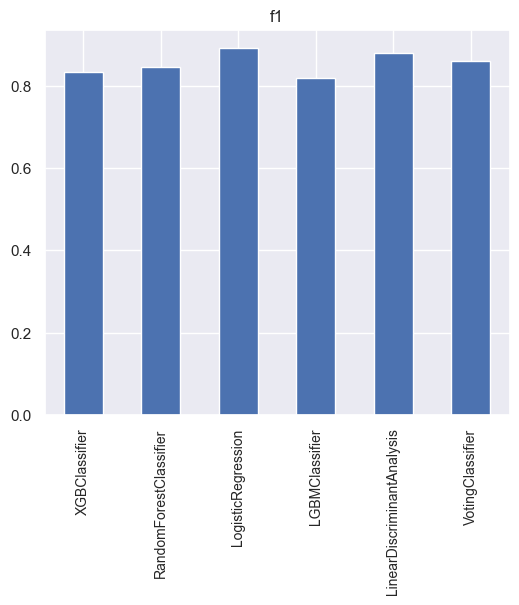

In [420]:
Metrics_df['f1'].plot(kind="bar",title='f1');

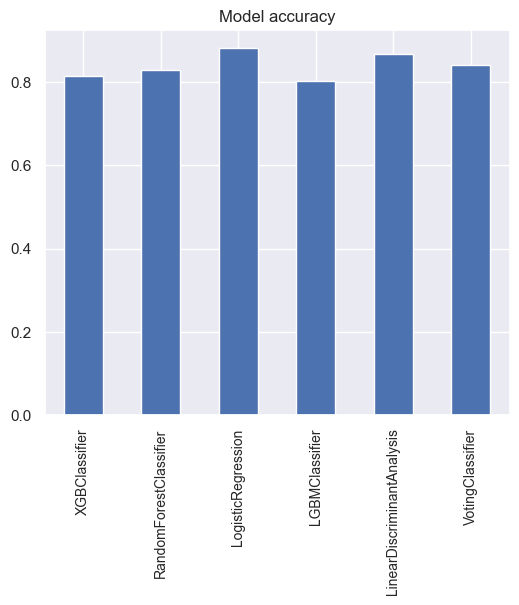

In [421]:
Metrics_df['accuracy'].plot(kind="bar", title='Model accuracy');

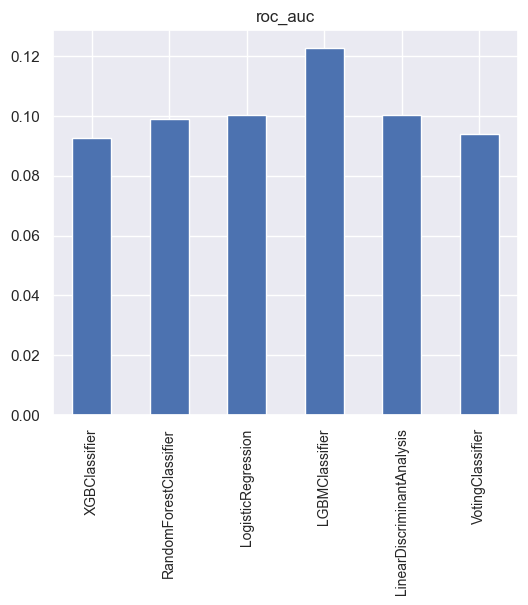

In [422]:
Metrics_df['roc_auc'].plot(kind="bar", title='roc_auc');

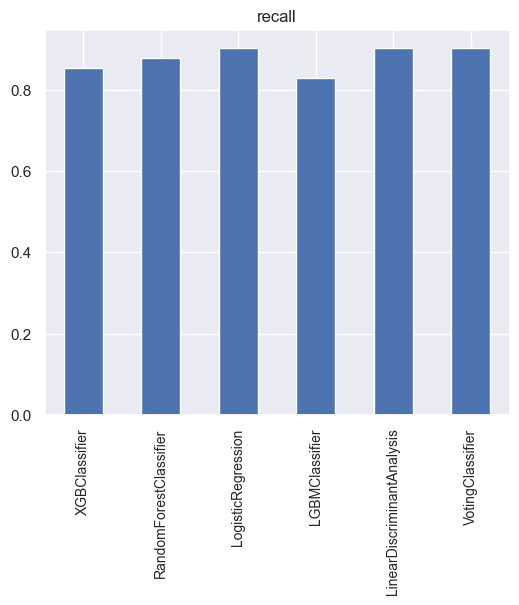

In [423]:
Metrics_df['recall'].plot(kind="bar", title='recall');

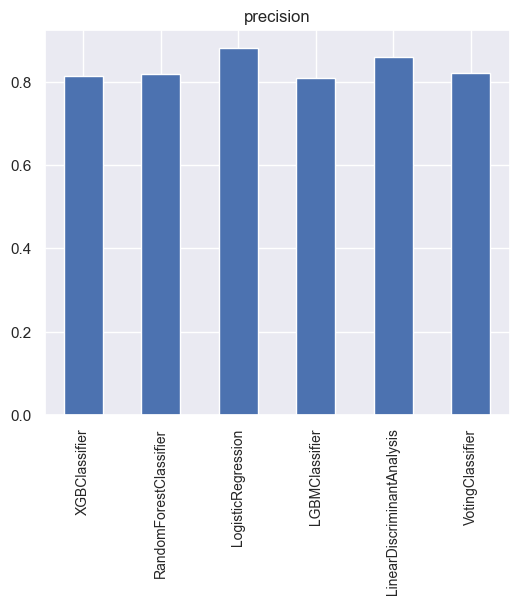

In [424]:
Metrics_df['precision'].plot(kind="bar", title='precision');